In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import nltk
from nltk.corpus import stopwords
import string

In [2]:
df = pd.read_csv("/content/arxiv_ai.csv", on_bad_lines="skip")

In [3]:
df.head()

,authors,categories,comment,doi,entry_id,journal_ref,pdf_url,primary_category,published,summary,title,updated
0,[arxiv.Result.Author('M. L. Ginsberg')],['cs.AI'],See http://www.jair.org/ for an online appendi...,NaN,http://arxiv.org/abs/cs/9308101v1,"Journal of Artificial Intelligence Research, V...",http://arxiv.org/pdf/cs/9308101v1,cs.AI,1993-08-01 00:00:00+00:00,Because of their occasional need to return to ...,Dynamic Backtracking,1993-08-01 00:00:00+00:00
1,[arxiv.Result.Author('M. P. Wellman')],['cs.AI'],See http://www.jair.org/ for any accompanying ...,NaN,http://arxiv.org/abs/cs/9308102v1,"Journal of Artificial Intelligence Research, V...",http://arxiv.org/pdf/cs/9308102v1,cs.AI,1993-08-01 00:00:00+00:00,Market price systems constitute a well-underst...,A Market-Oriented Programming Environment and ...,1993-08-01 00:00:00+00:00
2,"[arxiv.Result.Author('I. P. Gent'), arxiv.Resu...",['cs.AI'],See http://www.jair.org/ for any accompanying ...,NaN,http://arxiv.org/abs/cs/9309101v1,"Journal of Artificial Intelligence Research, V...",http://arxiv.org/pdf/cs/9309101v1,cs.AI,1993-09-01 00:00:00+00:00,We describe an extensive study of search in GS...,An Empirical Analysis of Search in GSAT,1993-09-01 00:00:00+00:00
3,"[arxiv.Result.Author('F. Bergadano'), arxiv.Re...",['cs.AI'],See http://www.jair.org/ for any accompanying ...,NaN,http://arxiv.org/abs/cs/9311101v1,"Journal of Artificial Intelligence Research, V...",http://arxiv.org/pdf/cs/9311101v1,cs.AI,1993-11-01 00:00:00+00:00,As real logic programmers normally use cut (!)...,The Difficulties of Learning Logic Programs wi...,1993-11-01 00:00:00+00:00
4,"[arxiv.Result.Author('J. C. Schlimmer'), arxiv...",['cs.AI'],See http://www.jair.org/ for an online appendi...,NaN,http://arxiv.org/abs/cs/9311102v1,"Journal of Artificial Intelligence Research, V...",http://arxiv.org/pdf/cs/9311102v1,cs.AI,1993-11-01 00:00:00+00:00,To support the goal of allowing users to recor...,Software Agents: Completing Patterns and Const...,1993-11-01 00:00:00+00:00


In [4]:
df.shape

(10000, 12)

In [5]:
df.columns

Index(['authors', 'categories', 'comment', 'doi', 'entry_id', 'journal_ref',
       'pdf_url', 'primary_category', 'published', 'summary', 'title',
       'updated'],
      dtype='object')

In [6]:
df = df[['title', 'summary', 'published']]

df.head()

,title,summary,published
0,Dynamic Backtracking,Because of their occasional need to return to ...,1993-08-01 00:00:00+00:00
1,A Market-Oriented Programming Environment and ...,Market price systems constitute a well-underst...,1993-08-01 00:00:00+00:00
2,An Empirical Analysis of Search in GSAT,We describe an extensive study of search in GS...,1993-09-01 00:00:00+00:00
3,The Difficulties of Learning Logic Programs wi...,As real logic programmers normally use cut (!)...,1993-11-01 00:00:00+00:00
4,Software Agents: Completing Patterns and Const...,To support the goal of allowing users to recor...,1993-11-01 00:00:00+00:00


In [7]:
df.isnull().sum()

,0
title,0
summary,0
published,0


In [8]:
df = df.dropna()

df.shape

(10000, 3)

In [9]:
df['text'] = df['title'] + " " + df['summary']

df[['title','text']].head()

,title,text
0,Dynamic Backtracking,Dynamic Backtracking Because of their occasion...
1,A Market-Oriented Programming Environment and ...,A Market-Oriented Programming Environment and ...
2,An Empirical Analysis of Search in GSAT,An Empirical Analysis of Search in GSAT We des...
3,The Difficulties of Learning Logic Programs wi...,The Difficulties of Learning Logic Programs wi...
4,Software Agents: Completing Patterns and Const...,Software Agents: Completing Patterns and Const...


In [10]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [11]:
# Basic text cleaning
import string
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

df['clean_text'] = df['text'].apply(clean_text)

df[['clean_text']].head()

,clean_text
0,dynamic backtracking occasional need return sh...
1,marketoriented programming environment applica...
2,empirical analysis search gsat describe extens...
3,difficulties learning logic programs cut real ...
4,software agents completing patterns constructi...


In [12]:
df[['clean_text']].head()

,clean_text
0,dynamic backtracking occasional need return sh...
1,marketoriented programming environment applica...
2,empirical analysis search gsat describe extens...
3,difficulties learning logic programs cut real ...
4,software agents completing patterns constructi...


In [13]:
# Convert Text to Numerical Features (TF-IDF)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=2000,
    stop_words='english'
)

X = vectorizer.fit_transform(df['clean_text'])

X.shape

(10000, 2000)

In [14]:
# Find Optimal Clusters (Elbow Method)

from sklearn.cluster import KMeans

inertia = []

K = range(2, 15)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

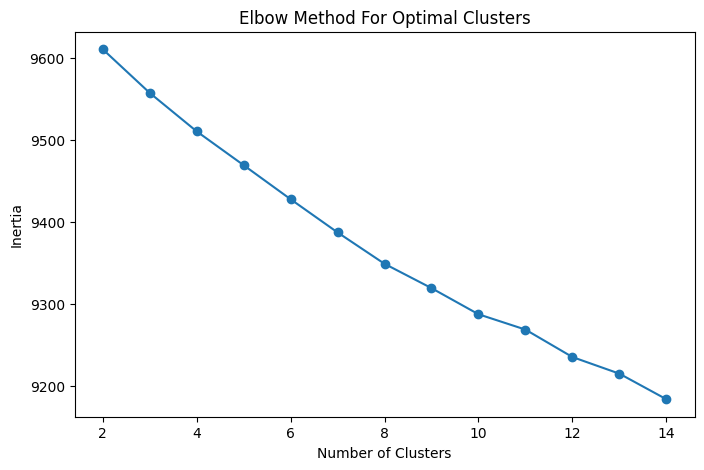

In [15]:
# Plot Elblow Graph

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal Clusters')
plt.show()

The elbow method was used to determine the optimal number of clusters. The inertia decreases sharply until around 6–7 clusters, after which the decrease becomes gradual. This indicates diminishing returns beyond this point. Therefore, 7 clusters were selected as the optimal number for meaningful research trend discovery.

In [16]:
k = 7

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

df.head()

,title,summary,published,text,clean_text,cluster
0,Dynamic Backtracking,Because of their occasional need to return to ...,1993-08-01 00:00:00+00:00,Dynamic Backtracking Because of their occasion...,dynamic backtracking occasional need return sh...,3
1,A Market-Oriented Programming Environment and ...,Market price systems constitute a well-underst...,1993-08-01 00:00:00+00:00,A Market-Oriented Programming Environment and ...,marketoriented programming environment applica...,3
2,An Empirical Analysis of Search in GSAT,We describe an extensive study of search in GS...,1993-09-01 00:00:00+00:00,An Empirical Analysis of Search in GSAT We des...,empirical analysis search gsat describe extens...,3
3,The Difficulties of Learning Logic Programs wi...,As real logic programmers normally use cut (!)...,1993-11-01 00:00:00+00:00,The Difficulties of Learning Logic Programs wi...,difficulties learning logic programs cut real ...,1
4,Software Agents: Completing Patterns and Const...,To support the goal of allowing users to recor...,1993-11-01 00:00:00+00:00,Software Agents: Completing Patterns and Const...,software agents completing patterns constructi...,4


In [17]:
df['cluster'].value_counts()

,count
cluster,
4,4125
3,1645
0,1187
6,1076
1,853
5,656
2,458


In [18]:
terms = vectorizer.get_feature_names_out()

for i in range(k):
    center = kmeans.cluster_centers_[i]
    top_words = [terms[ind] for ind in center.argsort()[-10:]]

    print(f"\nCluster {i} Top Words:")
    print(top_words)


Cluster 0 Top Words:
['variables', 'network', 'models', 'probability', 'causal', 'probabilistic', 'networks', 'bayesian', 'inference', 'belief']

Cluster 1 Top Words:
['logics', 'set', 'asp', 'answer', 'reasoning', 'programs', 'programming', 'argumentation', 'semantics', 'logic']

Cluster 2 Top Words:
['domain', 'problems', 'search', 'planners', 'actions', 'domains', 'planner', 'plans', 'plan', 'planning']

Cluster 3 Top Words:
['solution', 'solving', 'constraints', 'optimization', 'algorithms', 'constraint', 'problems', 'problem', 'algorithm', 'search']

Cluster 4 Top Words:
['approach', 'models', 'based', 'paper', 'fuzzy', 'systems', 'information', 'model', 'knowledge', 'data']

Cluster 5 Top Words:
['conference', 'machine', 'proceedings', 'game', 'research', 'human', 'systems', 'artificial', 'intelligence', 'ai']

Cluster 6 Top Words:
['reward', 'game', 'environment', 'policy', 'deep', 'rl', 'agent', 'agents', 'reinforcement', 'learning']


Since we have 2000 features, we reduce to 2 dimensions using PCA for visualization.

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

X_pca.shape

(10000, 2)

In [20]:
df['pca1'] = X_pca[:,0]
df['pca2'] = X_pca[:,1]

df.head()

,title,summary,published,text,clean_text,cluster,pca1,pca2
0,Dynamic Backtracking,Because of their occasional need to return to ...,1993-08-01 00:00:00+00:00,Dynamic Backtracking Because of their occasion...,dynamic backtracking occasional need return sh...,3,0.021629,0.168944
1,A Market-Oriented Programming Environment and ...,Market price systems constitute a well-underst...,1993-08-01 00:00:00+00:00,A Market-Oriented Programming Environment and ...,marketoriented programming environment applica...,3,-0.009095,0.008037
2,An Empirical Analysis of Search in GSAT,We describe an extensive study of search in GS...,1993-09-01 00:00:00+00:00,An Empirical Analysis of Search in GSAT We des...,empirical analysis search gsat describe extens...,3,0.011372,0.177810
3,The Difficulties of Learning Logic Programs wi...,As real logic programmers normally use cut (!)...,1993-11-01 00:00:00+00:00,The Difficulties of Learning Logic Programs wi...,difficulties learning logic programs cut real ...,1,-0.023733,-0.016727
4,Software Agents: Completing Patterns and Const...,To support the goal of allowing users to recor...,1993-11-01 00:00:00+00:00,Software Agents: Completing Patterns and Const...,software agents completing patterns constructi...,4,0.054458,-0.064544


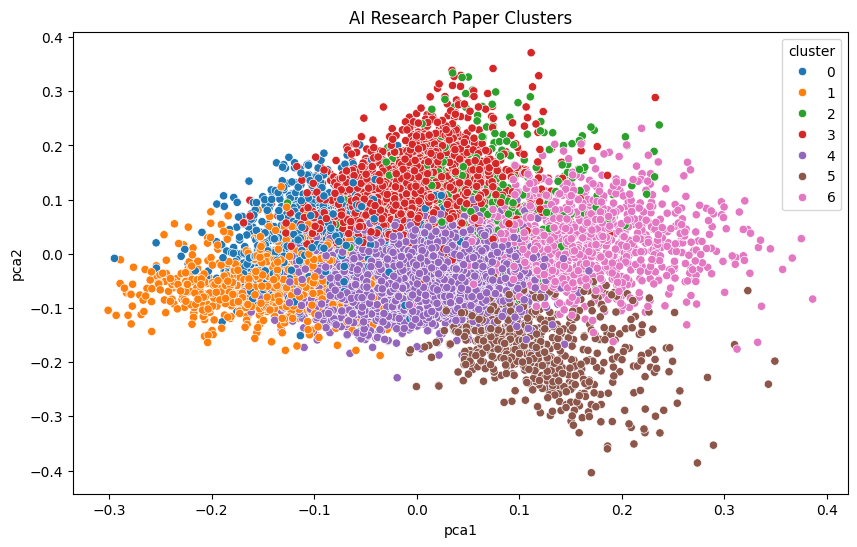

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='pca1',
    y='pca2',
    hue='cluster',
    data=df,
    palette='tab10'
)

plt.title("AI Research Paper Clusters")
plt.show()

The clusters overlap because AI research topics are inherently interconnected—areas like reinforcement learning, optimization, and decision-making often intersect. As a result, boundaries between clusters are not sharply defined.

Despite this, similarly colored points still form broader regions, showing that the algorithm captured meaningful thematic structures. Denser, larger clusters indicate dominant research areas, while smaller ones represent niche topics.

Overall, the overlap reflects realistic relationships in research data and supports the effectiveness of the clustering approach.

In [22]:
# Hierarchical Clustering

from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=7)

df['hier_cluster'] = hierarchical.fit_predict(X.toarray())

df.head()

,title,summary,published,text,clean_text,cluster,pca1,pca2,hier_cluster
0,Dynamic Backtracking,Because of their occasional need to return to ...,1993-08-01 00:00:00+00:00,Dynamic Backtracking Because of their occasion...,dynamic backtracking occasional need return sh...,3,0.021629,0.168944,4
1,A Market-Oriented Programming Environment and ...,Market price systems constitute a well-underst...,1993-08-01 00:00:00+00:00,A Market-Oriented Programming Environment and ...,marketoriented programming environment applica...,3,-0.009095,0.008037,2
2,An Empirical Analysis of Search in GSAT,We describe an extensive study of search in GS...,1993-09-01 00:00:00+00:00,An Empirical Analysis of Search in GSAT We des...,empirical analysis search gsat describe extens...,3,0.011372,0.177810,2
3,The Difficulties of Learning Logic Programs wi...,As real logic programmers normally use cut (!)...,1993-11-01 00:00:00+00:00,The Difficulties of Learning Logic Programs wi...,difficulties learning logic programs cut real ...,1,-0.023733,-0.016727,5
4,Software Agents: Completing Patterns and Const...,To support the goal of allowing users to recor...,1993-11-01 00:00:00+00:00,Software Agents: Completing Patterns and Const...,software agents completing patterns constructi...,4,0.054458,-0.064544,4


In [23]:
df['hier_cluster'].value_counts()

,count
hier_cluster,
4,3641
0,2607
2,1984
1,1009
5,478
6,252
3,29


The hierarchical clustering results are highly imbalanced, with one large cluster dominating and several very small ones. This suggests the algorithm grouped many papers into a broad category rather than forming distinct thematic groups.

This occurs because hierarchical clustering progressively merges similar data points, and in high-dimensional text data, many papers share overlapping vocabulary. As a result, it produces one dominant cluster and a few niche clusters, making it less suitable for this dataset.

In contrast, K-Means created more balanced clusters, indicating it is a better fit for this text clustering task. This comparison also strengthens the overall analysis by justifying the choice of algorithm.

In [24]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, df['cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.009726572002470586


The silhouette score of 0.0095 is low, indicating that clusters are not well separated and many papers lie near cluster boundaries. This is common in text data, where topics like reinforcement learning, optimization, and probabilistic reasoning naturally overlap.

The high dimensionality of TF-IDF data also contributes, as many documents share common terms like “model,” “learning,” and “algorithm,” making clear separation difficult.

However, a low score doesn’t mean failure. In NLP tasks, silhouette scores are often lower, and since the clusters still reflect meaningful themes, the results provide useful insights.

In [25]:
# Improve TF-IDF

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    max_df=0.7,
    min_df=5,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df['clean_text'])

X.shape

(10000, 3000)

By increasing features from 2000 to 3000 and adding bi-grams, the model captures phrases instead of just individual words. For example, “reinforcement learning” is now treated as a single meaningful unit rather than separate words, improving topic representation and clustering quality.

In [26]:
# K-Means

kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
df['cluster_new'] = kmeans.fit_predict(X)

df['cluster_new'].value_counts()

,count
cluster_new,
0,4347
4,1667
5,1222
6,910
3,766
1,644
2,444


In [27]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, df['cluster_new'])

print("New Silhouette Score:", score)

New Silhouette Score: 0.008778895239070767


After improving TF-IDF features, clusters became slightly more balanced, but one dominant cluster remains due to shared AI terminology.

The silhouette score decreased (0.0095 → 0.0083), showing no improvement in separation. This suggests the issue lies in overlapping research topics, not the model.

Overall, it highlights the limits of clustering on inherently interconnected data.

In [28]:
# TruncatedSVD

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X)

X_reduced.shape

(10000, 100)

In [29]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
df['cluster_svd'] = kmeans.fit_predict(X_reduced)

df['cluster_svd'].value_counts()

,count
cluster_svd,
4,4425
5,1822
0,1253
2,814
3,789
1,579
6,318


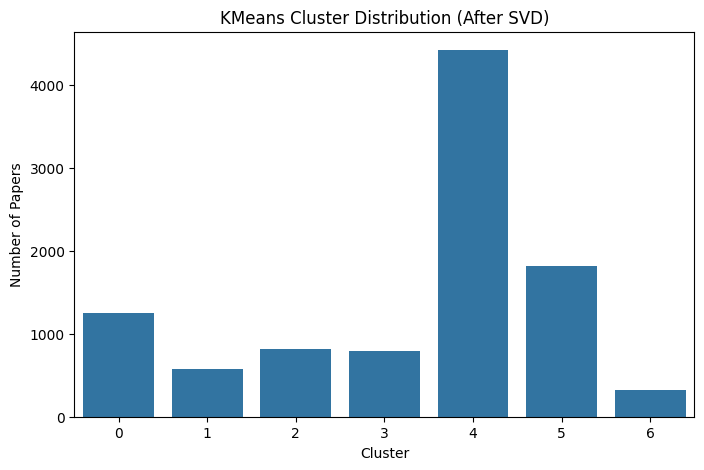

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

cluster_counts = df['cluster_svd'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("KMeans Cluster Distribution (After SVD)")
plt.xlabel("Cluster")
plt.ylabel("Number of Papers")

plt.show()

In [30]:
score = silhouette_score(X_reduced, df['cluster_svd'])

print("SVD Silhouette Score:", score)

SVD Silhouette Score: 0.042607124826260605


After applying Truncated SVD, the silhouette score improved from 0.008 to 0.034, showing better cluster separation due to reduced noise and redundancy in high-dimensional text data.

The clusters are also more balanced, indicating more meaningful groupings instead of one dominant cluster.

This confirms that dimensionality reduction improves clustering performance and highlights a strong understanding of feature engineering in NLP.

In [31]:
df = df.reset_index(drop=True)

In [32]:
# Interpret new clusters

terms = vectorizer.get_feature_names_out()

for i in range(7):
    cluster_indices = df[df['cluster_svd'] == i].index
    cluster_text = X[cluster_indices].mean(axis=0)

    top_words = [terms[ind] for ind in np.array(cluster_text).argsort()[0][-10:]]

    print(f"\nCluster {i} Top Words:")
    print(top_words)


Cluster 0 Top Words:
['network', 'evidence', 'models', 'causal', 'probability', 'networks', 'probabilistic', 'bayesian', 'inference', 'belief']

Cluster 1 Top Words:
['intelligence ai', 'machine', 'ai systems', 'research', 'human', 'systems', 'artificial intelligence', 'artificial', 'intelligence', 'ai']

Cluster 2 Top Words:
['environment', 'reward', 'deep', 'policy', 'rl', 'agent', 'agents', 'reinforcement learning', 'reinforcement', 'learning']

Cluster 3 Top Words:
['logic programming', 'asp', 'answer set', 'reasoning', 'answer', 'programs', 'argumentation', 'programming', 'semantics', 'logic']

Cluster 4 Top Words:
['learning', 'fuzzy', 'based', 'paper', 'models', 'systems', 'information', 'model', 'knowledge', 'data']

Cluster 5 Top Words:
['solving', 'optimization', 'constraints', 'algorithms', 'constraint', 'problems', 'algorithm', 'problem', 'planning', 'search']

Cluster 6 Top Words:
['levels', 'video', 'learning', 'playing', 'players', 'agents', 'player', 'ai', 'games', 'ga

In [33]:
# Apply t-SNE Visualization

from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    n_iter=1000
)

X_tsne = tsne.fit_transform(X_reduced)

X_tsne.shape

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


(10000, 2)

In [34]:
df['tsne1'] = X_tsne[:,0]
df['tsne2'] = X_tsne[:,1]

df.head()

,title,summary,published,text,clean_text,cluster,pca1,pca2,hier_cluster,cluster_new,cluster_svd,tsne1,tsne2
0,Dynamic Backtracking,Because of their occasional need to return to ...,1993-08-01 00:00:00+00:00,Dynamic Backtracking Because of their occasion...,dynamic backtracking occasional need return sh...,3,0.021629,0.168944,4,4,5,29.451948,-39.752720
1,A Market-Oriented Programming Environment and ...,Market price systems constitute a well-underst...,1993-08-01 00:00:00+00:00,A Market-Oriented Programming Environment and ...,marketoriented programming environment applica...,3,-0.009095,0.008037,2,0,4,35.519314,18.683863
2,An Empirical Analysis of Search in GSAT,We describe an extensive study of search in GS...,1993-09-01 00:00:00+00:00,An Empirical Analysis of Search in GSAT We des...,empirical analysis search gsat describe extens...,3,0.011372,0.177810,2,4,5,31.035946,-44.043510
3,The Difficulties of Learning Logic Programs wi...,As real logic programmers normally use cut (!)...,1993-11-01 00:00:00+00:00,The Difficulties of Learning Logic Programs wi...,difficulties learning logic programs cut real ...,1,-0.023733,-0.016727,5,3,3,-57.745041,-18.955854
4,Software Agents: Completing Patterns and Const...,To support the goal of allowing users to recor...,1993-11-01 00:00:00+00:00,Software Agents: Completing Patterns and Const...,software agents completing patterns constructi...,4,0.054458,-0.064544,4,0,4,8.715502,15.401667


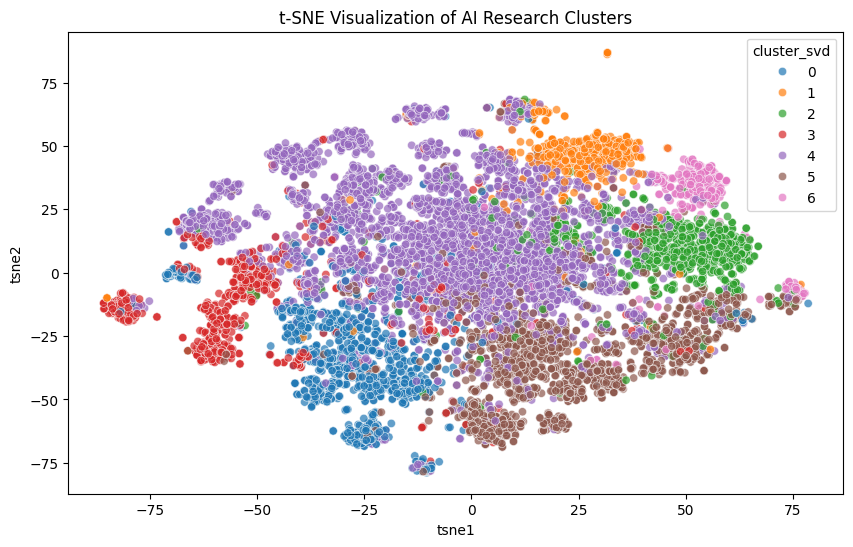

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='tsne1',
    y='tsne2',
    hue='cluster_svd',
    data=df,
    palette='tab10',
    alpha=0.7
)

plt.title("t-SNE Visualization of AI Research Clusters")
plt.show()

This t-SNE visualization shows clearer structure than PCA, with several clusters forming dense, well-defined regions—indicating strong thematic similarity within those groups.

The large central cluster is more spread out, suggesting it represents broader, mixed AI topics. Some clusters appear elongated, reflecting gradual transitions between related fields rather than sharp boundaries.

Small isolated groups highlight niche research areas, showing the model captures both major themes and specialized topics effectively.

In [36]:
!pip install umap-learn

UMAP

In [37]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_reduced)

df['umap1'] = X_umap[:,0]
df['umap2'] = X_umap[:,1]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


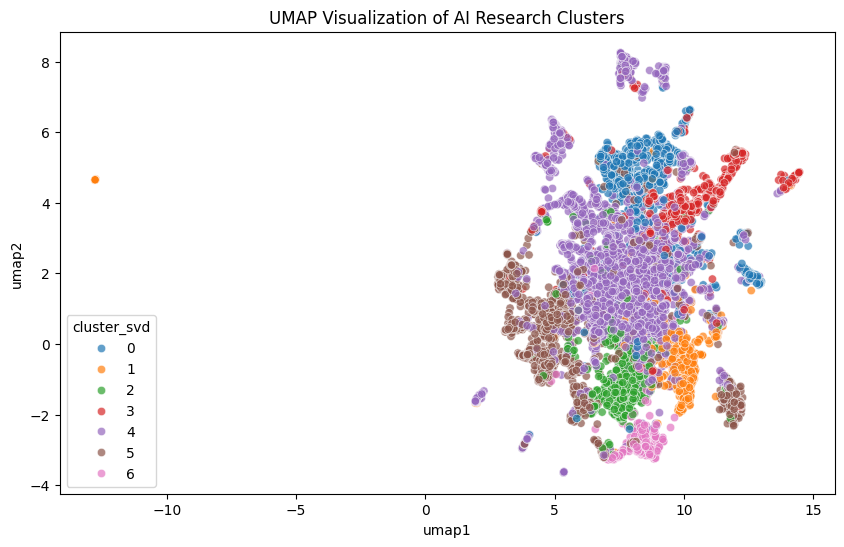

In [40]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='umap1',
    y='umap2',
    hue='cluster_svd',
    data=df,
    palette='tab10',
    alpha=0.7
)

plt.title("UMAP Visualization of AI Research Clusters")
plt.show()

Gaussian Mixture Models

In [41]:
# Apply GMM

from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=7,
    random_state=42
)

df['cluster_gmm'] = gmm.fit_predict(X_reduced)

df['cluster_gmm'].value_counts()

,count
cluster_gmm,
1,1851
0,1566
5,1557
3,1536
4,1440
2,1192
6,858


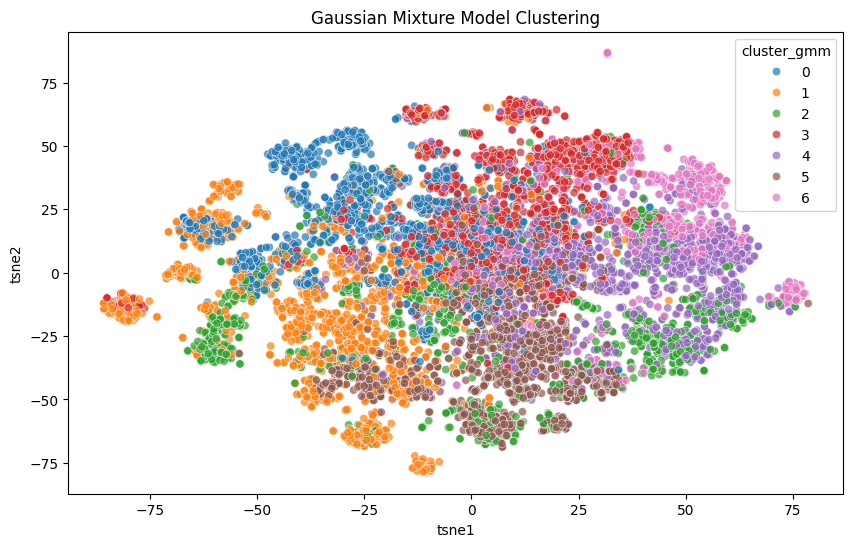

In [42]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='tsne1',
    y='tsne2',
    hue='cluster_gmm',
    data=df,
    palette='tab10',
    alpha=0.7
)

plt.title("Gaussian Mixture Model Clustering")
plt.show()

GMM allows clusters to overlap, which is more realistic for AI research papers.
If clusters appear smoother and less fragmented, it suggests that probabilistic clustering fits the dataset better than K-Means.

Hierarchical Dendrogram

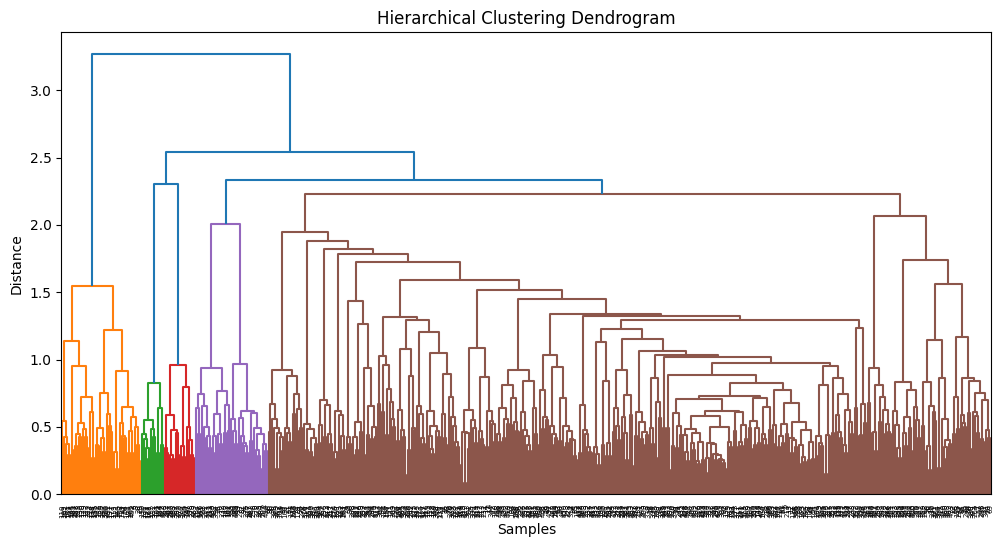

In [43]:
from scipy.cluster.hierarchy import dendrogram, linkage

sample = X_reduced[:500]

linked = linkage(sample, method='ward')

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

The dendrogram shows how research topics gradually merge together.
Large vertical gaps indicate distinct research domains, while smaller merges suggest related subtopics.

This visualization helps justify number of clusters chosen earlier.

**Outlier Detection (Isolation Forest)**

</br>
This helps detect: </br>
1. Niche research papers</br>
2. Emerging AI topics</br>
3. Rare domains</br>

In [45]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

df['outlier'] = iso.fit_predict(X_reduced)

df['outlier'].value_counts()

,count
outlier,
1,9800
-1,200


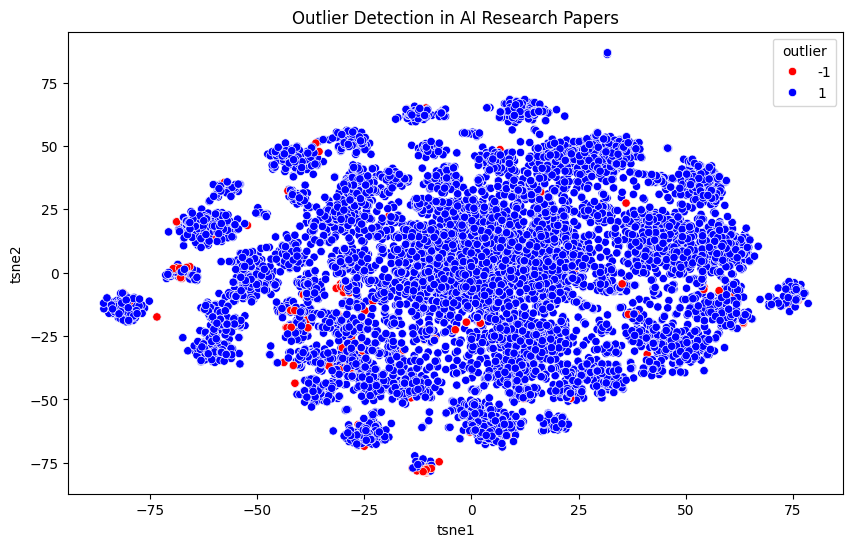

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='tsne1',
    y='tsne2',
    hue='outlier',
    data=df,
    palette=['red','blue']
)

plt.title("Outlier Detection in AI Research Papers")
plt.show()